In [1]:
## Imports and prereqs
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import yaml

foldname = 'Day1'
filename = '01062026DataMUODelay.csv'

if "data" not in os.getcwd():
    path = os.path.join(os.path.dirname(os.getcwd()), 'data', foldname)
    os.chdir(path)


Total counts: 436110.0


C:\Users\Dumitru Andrei\AppData\Local\Temp\ipykernel_20028\482454600.py:4: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=1`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  head = np.loadtxt(filename, delimiter=',', dtype=str  , max_rows=1)


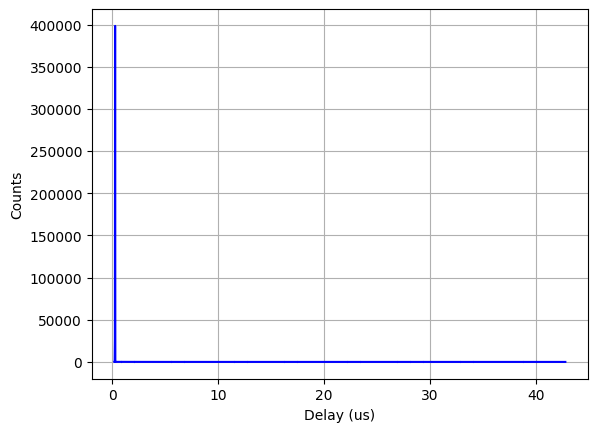

In [2]:
## Load the data file

data = np.loadtxt(filename, delimiter=',', dtype=float, skiprows=1)
head = np.loadtxt(filename, delimiter=',', dtype=str  , max_rows=1)

dlvals = data[:,0]
dlerrs = data[:,1]
counts = data[:,2]

print(f"Total counts: {np.sum(counts)}")

plt.errorbar(dlvals, counts, color = 'blue', xerr = dlerrs)
plt.ylabel('Counts')
plt.xlabel('Delay (us)')
#plt.ylim((0,120))
plt.grid()
plt.show()

Total counts: 9493.0


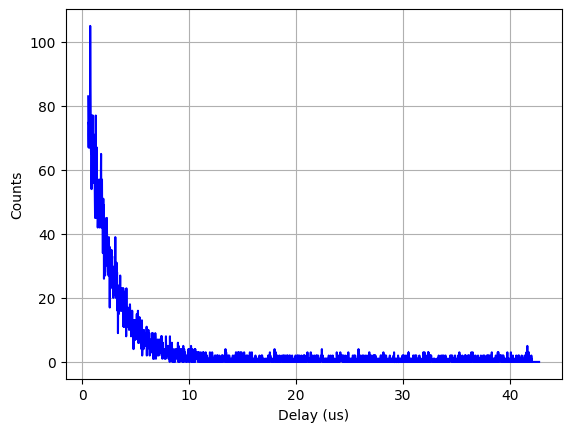

In [33]:
## Filter initial noise peak

# NOTE: Filter only the initial noise peak, no more no less! Filtering more will give erroneous values.
# i.e. filterIndex = 5


justTesting = False # Change to False when you want to permanently change the arrays
filterindex = 1

if justTesting is False:
    dlvals = dlvals[filterindex:]
    dlerrs = dlerrs[filterindex:]
    counts = counts[filterindex:]

print(f"Total counts: {np.sum(counts)}")

plt.errorbar(dlvals[filterindex:], counts[filterindex:], color = 'blue', xerr = dlerrs[filterindex:])
plt.ylabel('Counts')
plt.xlabel('Delay (us)')
#plt.ylim((0,120))
plt.grid()
plt.show()

In [34]:
## Fit the exponential
import odrpack

# Linear fitting def
def fitting_funct(xVal, params: np.ndarray):
    '''Fitting function for the given datapoints'''
    return params[0]*np.exp(-xVal/params[1]) + params[2] 

#popt, _ = scipy.optimize.curve_fit(lambda x,a,b,c: fitting_funct(x,[a,b,c]), dlvals, counts, sigma=1)

popt = np.array([100, 2.3, 0.5])

# Models, 5% error for delays, 1 error for counts
output = odrpack.odr_fit(fitting_funct, dlvals, counts, popt, 
                         weight_x=1/(dlerrs), weight_y=1/(np.sqrt(1+counts)),
                         bounds = [0.8*popt,1.15*popt])

#print(output.beta)
#print(output.cov_beta)

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

[103.27648606   2.06704224   0.51297225]
Lower bounds: [80.    1.84  0.4 ]
Upper bounds: [115.      2.645   0.575]
Statistical error on parameter 0: 0.82%
Statistical error on parameter 1: 0.76%
Statistical error on parameter 2: 5.42%


Muon lifetime: 2.0670422403363276 +/- 0.01567808427243025
C: 0.5129722527811712 +/- 0.027784515739001932


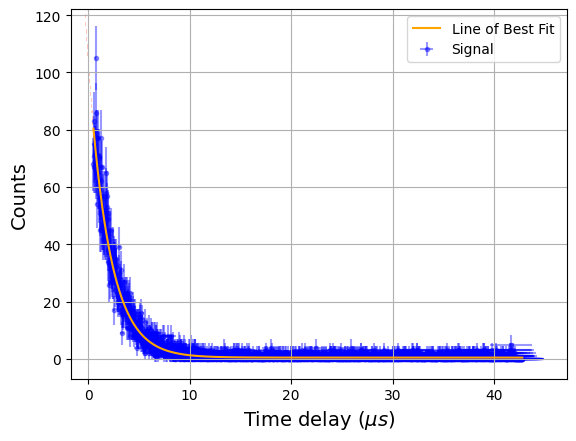

In [35]:
# Plot data and fit

plotRange = np.linspace(min(dlvals), max(dlvals), 1000)

print(rf"Muon lifetime: {output.beta[1]} +/- {np.sqrt(output.cov_beta[1][1])}")
print(rf"C: {output.beta[2]} +/- {np.sqrt(output.cov_beta[2][2])}")

plt.errorbar(dlvals, counts, xerr=0.05*dlvals, yerr = 1+np.sqrt(counts), fmt='.', color = 'blue', alpha = 0.4, zorder=0, label = 'Signal')
plt.plot(plotRange, fitting_funct(plotRange, [output.beta[0], output.beta[1], output.beta[2]]), color = 'orange', alpha = 1, label = 'Line of Best Fit')

xrange = np.linspace(plt.xlim()[0],plt.xlim()[1], 1000)
yrange = np.linspace(plt.ylim()[0],plt.ylim()[1], 1000)

X, Y = np.meshgrid(xrange, yrange)

Ymin = fitting_funct(X, [output.beta[0]-output.cov_beta[0][0], 
                         output.beta[1]-output.cov_beta[1][1], 
                         output.beta[2]-output.cov_beta[2][2]])
Ymax = fitting_funct(X, [output.beta[0]+output.cov_beta[0][0], 
                         output.beta[1]+output.cov_beta[1][1], 
                         output.beta[2]+output.cov_beta[2][2]])

Z = np.logical_and(np.less(Y, Ymax) , np.less(Ymin, Y))

plt.contourf(X ,Y ,Z ,levels = [0.99, 1.01], cmap = 'Reds', alpha = 0.35)

plt.xlabel(r"Time delay ($\mu s$)", fontdict = {'size' : 14})
plt.ylabel("Counts" , fontdict = {'size' : 14})
plt.grid()
plt.legend()
plt.show()

In [14]:
## Separate fitting procedure

def fitting_funct_1(xVal, params: np.ndarray):
    '''Fitting function for region 1'''
    return params[0]*np.exp(-xVal/params[1]) + params[2] 

def fitting_funct_2(xVal, params: np.ndarray):
    '''Fitting function for region 2'''
    return params[0] + 0*xVal 



# Separation index
separator = 474

# Section 1
dlvals1 = dlvals[:separator]
counts1 = counts[:separator]
dlerrs1 = dlerrs[:separator]

# Section 2
dlvals2 = dlvals[separator:]
counts2 = counts[separator:]
dlerrs2 = dlerrs[separator:]

# Sect 1
print("Section 1:")
popt = np.array([115, 2.5, -0.3])

# Models, 5% error for delays, 1 error for counts
output = odrpack.odr_fit(fitting_funct_1, dlvals1, counts1, popt, 
                         weight_x=1/(dlerrs1), weight_y=1/(np.sqrt(1+counts1)),
                         bounds = [[0.8*popt[0],0.8*popt[1],1.15*popt[2]],[1.15*popt[0],1.15*popt[1],0.8*popt[2]]])

#print(output.beta)
#print(output.cov_beta)

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

params1 = output.beta
paramerr1 = output.cov_beta
# Sect 2
print("Section 2:")
popt = np.array([0.5])

# Models, 5% error for delays, 1 error for counts
output = odrpack.odr_fit(fitting_funct_2, dlvals2, counts2, popt, 
                         weight_x=1/(dlerrs2), weight_y=1/(np.sqrt(1+counts2)),
                         bounds = [0.8*popt,1.15*popt])

#print(output.beta)
#print(output.cov_beta)

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

params2 = output.beta
paramerr2 = output.cov_beta

Section 1:
[93.04957737  2.30548798 -0.31661504]
Lower bounds: [92.    2.   -0.24]
Upper bounds: [132.25    2.875  -0.345]
Statistical error on parameter 0: 0.72%
Statistical error on parameter 1: 1.15%
Statistical error on parameter 2: 51.09%
Section 2:
[0.5581032]
Lower bounds: [0.4]
Upper bounds: [0.575]
Statistical error on parameter 0: 4.99%


Muon lifetime: 2.305487977416664 +/- 0.02655028164659018
C1: -0.3166150430278975 +/- 0.1617713874020885
C2: 0.5581031989483328 +/- 0.027849104502682832


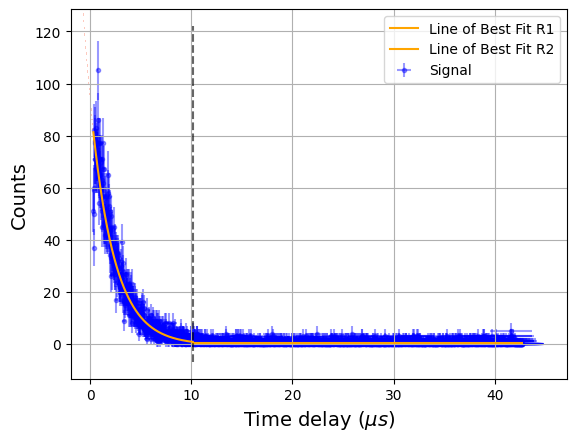

In [15]:
# Plot data and fit

plotRange1 = np.linspace(min(dlvals1), max(dlvals1), 1000)
plotRange2 = np.linspace(min(dlvals2), max(dlvals2), 1000)

print(rf"Muon lifetime: {params1[1]} +/- {np.sqrt(paramerr1[1][1])}")
print(rf"C1: {params1[2]} +/- {np.sqrt(paramerr1[2][2])}")
print(rf"C2: {params2[0]} +/- {np.sqrt(paramerr2[0][0])}")

plt.errorbar(dlvals, counts, xerr=0.05*dlvals, yerr = 1+np.sqrt(counts), fmt='.', color = 'blue', alpha = 0.4, zorder=0, label = 'Signal')
plt.plot(plotRange1, fitting_funct_1(plotRange1, [params1[0], params1[1], params1[2]]), color = 'orange', alpha = 1, label = 'Line of Best Fit R1')
plt.plot(plotRange2, fitting_funct_2(plotRange1, [params2[0]]), color = 'orange', alpha = 1, label = 'Line of Best Fit R2')
plt.vlines(dlvals[separator], ymin=plt.ylim()[0], ymax= plt.ylim()[1], color = 'black',linestyles= 'dashed', alpha = 0.6) 

xrange = np.linspace(plt.xlim()[0],plt.xlim()[1], 1000)
yrange = np.linspace(plt.ylim()[0],plt.ylim()[1], 1000)

X, Y = np.meshgrid(xrange, yrange)

Ymin = fitting_funct_1(X, [params1[0]-paramerr1[0][0], 
                         params1[1]-paramerr1[1][1], 
                         params1[2]-paramerr1[2][2]])
Ymax = fitting_funct_1(X, [params1[0]+paramerr1[0][0], 
                         params1[1]+paramerr1[1][1], 
                         params1[2]+paramerr1[2][2]])

Z = np.logical_and(np.less(Y, Ymax) , np.less(Ymin, Y))

plt.contourf(X ,Y ,Z ,levels = [0.99, 1.01], cmap = 'Reds', alpha = 0.35)

plt.xlabel(r"Time delay ($\mu s$)", fontdict = {'size' : 14})
plt.ylabel("Counts" , fontdict = {'size' : 14})
plt.grid()
plt.legend()
plt.show()